## Range Angle Experiment

### Dependencies and Configuration

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

from ifxradarsdk.fmcw.types import FmcwSimpleSequenceConfig, FmcwSequenceChirp

config = FmcwSimpleSequenceConfig(
    frame_repetition_time_s=0.08,
    chirp_repetition_time_s=0.00035,
    num_chirps=128,
    tdm_mimo=False,
    chirp=FmcwSequenceChirp(
        start_frequency_Hz=58.0e9,
        end_frequency_Hz=63.5e9,
        sample_rate_Hz=2_000_000,
        num_samples=64,
        rx_mask=0b111,
        tx_mask=0b001,
        tx_power_level=18,
        lp_cutoff_Hz=500_000,
        hp_cutoff_Hz=20_000,
        if_gain_dB=20
    )
)

num_beams = 11
range_bin_size = 0.027254   # meters (2.7254 cm)

### Pre-made Functions and Classes

In [33]:
def fft_spectrum(mat, range_window):
    # Calculate fft spectrum
    # mat:          chirp data
    # range_window: window applied on input data before fft

    # received data 'mat' is in matrix form for a single receive antenna
    # each row contains 'num_samples' for a single chirp
    # total number of rows = 'num_chirps'

    # -------------------------------------------------
    # Step 1 - remove DC bias from samples
    # -------------------------------------------------
    [num_chirps, num_samples] = np.shape(mat)

    # helpful in zero padding for high resolution FFT.
    # compute row (chirp) averages
    avgs = np.average(mat, 1).reshape(num_chirps, 1)

    # de-bias values
    mat = mat - avgs
    # -------------------------------------------------
    # Step 2 - Windowing the Data
    # -------------------------------------------------
    mat = np.multiply(mat, range_window)

    # -------------------------------------------------
    # Step 3 - add zero padding here
    # -------------------------------------------------
    zp1 = np.pad(mat, ((0, 0), (0, num_samples)), 'constant')

    # -------------------------------------------------
    # Step 4 - Compute FFT for distance information
    # -------------------------------------------------
    range_fft = np.fft.fft(zp1) / num_samples

    # ignore the redundant info in negative spectrum
    # compensate energy by doubling magnitude
    range_fft = 2 * range_fft[:, range(int(num_samples))]

    return range_fft
class DopplerAlgo:
    """Compute Range-Doppler map"""

    def __init__(self, num_samples: int, num_chirps_per_frame: int, num_ant: int, mti_alpha: float = 0.8):
        """Create Range-Doppler map object

        Parameters:
            - num_samples:          Number of samples in a single chirp
            - num_chirps_per_frame: Number of chirp repetitions within a measurement frame
            - num_ant:              Number of antennas
            - mti_alpha:            Parameter alpha of Moving Target Indicator
        """
        self.num_chirps_per_frame = num_chirps_per_frame

        # compute Blackman-Harris Window matrix over chirp samples(range)
        try:
            self.range_window = signal.blackmanharris(num_samples).reshape(1, num_samples)
        except AttributeError:
            self.range_window = signal.windows.blackmanharris(num_samples).reshape(1, num_samples)

        # compute Blackman-Harris Window matrix over number of chirps(velocity)
        try:
            self.doppler_window = signal.blackmanharris(self.num_chirps_per_frame).reshape(1, self.num_chirps_per_frame)
        except AttributeError:
            self.doppler_window = signal.windows.blackmanharris(self.num_chirps_per_frame).reshape(1, self.num_chirps_per_frame)
            
        # parameter for moving target indicator (MTI)
        self.mti_alpha = mti_alpha

        # initialize MTI filter
        self.mti_history = np.zeros((self.num_chirps_per_frame, num_samples, num_ant))

    def compute_doppler_map(self, data: np.ndarray, i_ant: int):
        """Compute Range-Doppler map for i-th antennas

        Parameter:
            - data:     Raw-data for one antenna (dimension:
                        num_chirps_per_frame x num_samples)
            - i_ant:    RX antenna index
        """
        # Step 1 - Remove average from signal (mean removal)
        data = data - np.average(data)

        # Step 2 - MTI processing to remove static objects
        data_mti = data - self.mti_history[:, :, i_ant]
        self.mti_history[:, :, i_ant] = data * self.mti_alpha + self.mti_history[:, :, i_ant] * (1 - self.mti_alpha)

        # Step 3 - calculate fft spectrum for the frame
        fft1d = fft_spectrum(data_mti, self.range_window)

        # prepare for doppler FFT

        # Transpose
        # Distance is now indicated on y axis
        fft1d = np.transpose(fft1d)

        # Step 4 - Windowing the Data in doppler
        fft1d = np.multiply(fft1d, self.doppler_window)

        zp2 = np.pad(fft1d, ((0, 0), (0, self.num_chirps_per_frame)), "constant")
        fft2d = np.fft.fft(zp2) / self.num_chirps_per_frame

        # re-arrange fft result for zero speed at centre
        return np.fft.fftshift(fft2d, (1,))
    
class DigitalBeamForming:
    def __init__(self, num_antennas: int, num_beams: int = 27, max_angle_degrees: float = 45, d_by_lambda: float = 0.5):
        """Create a Digital Beam Forming object

        Parameters:
            - num_antennas:         number of (virtual) RX antennas
            - num_beams:            number of beams
            - max_angle_degrees:    maximum angle in degrees, angles will range
                                    from -max_angle_degrees .. +max_angle_degrees
            - d_by_lambda:          separation of RX antennas divided by the wavelength
        """
        angle_vector = np.radians(np.linspace(-max_angle_degrees, max_angle_degrees, num_beams))

        weights = np.zeros((num_antennas, num_beams), dtype=complex)

        for iBeam in range(num_beams):
            angle = angle_vector[iBeam]
            for iAntenna in range(num_antennas):
                weights[iAntenna, iBeam] = np.exp(
                    1j * 2 * np.pi * iAntenna * d_by_lambda * np.sin(angle))  # /sqrt(num_antennas)

        self.weights = weights

    def run(self, range_doppler):
        """Compute virtual beams

        Parameters:
            - range_doppler: Range Doppler spectrum for all RX antennas
              (dimension: num_samples_per_chirp x num_chirps_per_frame x
              num_antennas)
        
        Returns:
            - Range Doppler Beams (dimension: num_samples_per_chirp x
              num_chirps_per_frame x num_beams)
        """

        num_samples, num_chirps, num_antennas = range_doppler.shape

        num_antennas_internal, num_beams = self.weights.shape

        assert num_antennas == num_antennas_internal

        rd_beam_formed = np.zeros((num_samples, num_chirps, num_beams), dtype=complex);

        for iBeam in range(num_beams):
            acc = np.zeros((num_samples, num_chirps), dtype=complex)

            for iAntenna in range(num_antennas):
                acc += range_doppler[:, :, iAntenna] * self.weights[num_antennas - iAntenna - 1, iBeam]

            rd_beam_formed[:, :, iBeam] = acc

        return rd_beam_formed


def num_rx_antennas_from_rx_mask(rx_mask):
    # popcount for rx_mask
    c = 0
    for i in range(32):
        if rx_mask & (1 << i):
            c += 1
    return c

num_rx_antennas = num_rx_antennas_from_rx_mask(config.chirp.rx_mask)
doppler = DopplerAlgo(config.chirp.num_samples,
                        config.num_chirps, num_rx_antennas)
dbf = DigitalBeamForming(
    num_rx_antennas, num_beams=num_beams, max_angle_degrees=max_angle_degrees, d_by_lambda=0.25)
def plot_mean_beam_range_map(mean_beam_range_energy, max_angle_degrees, max_range_m=10, title_add_on=""):
    """Plot a static Range-Angle map for the averaged beam-range energy."""

    # Color scaling — same as Infineon's demo
    # vmin, vmax = -60, 0
    vmin, vmax = mean_beam_range_energy.min(), mean_beam_range_energy.max()

    plt.figure(figsize=(8, 3))
    plt.imshow(
        mean_beam_range_energy,
        vmin=vmin, vmax=vmax,
        cmap='viridis',
        extent=(-max_angle_degrees, max_angle_degrees, 0, max_range_m),
        origin='lower',
        aspect='auto'
    )
    plt.xlabel("Angle (degrees)")
    plt.ylabel("Range (cm)")
    plt.title("Mean Range-Angle Map using Digital Beam Forming" + title_add_on)

    cbar = plt.colorbar()
    cbar.set_label("Magnitude (a.u.)")

    plt.tight_layout()
    plt.show()

### Adapted code

In [34]:
def range_angle_matrix(frame):
    rd_spectrum = np.zeros(
        (config.chirp.num_samples, 2 * config.num_chirps, num_rx_antennas), dtype=complex)

    beam_range_energy = np.zeros((config.chirp.num_samples, num_beams))

    for i_ant in range(num_rx_antennas):  # For each antenna
        # Current RX antenna (num_samples_per_chirp x num_chirps_per_frame)
        mat = frame[i_ant, :, :]

        # Compute Doppler spectrum
        dfft_dbfs = doppler.compute_doppler_map(mat, i_ant)
        rd_spectrum[:, :, i_ant] = dfft_dbfs

    # Compute Range-Angle map
    rd_beam_formed = dbf.run(rd_spectrum)
    for i_beam in range(num_beams):
        doppler_i = rd_beam_formed[:, :, i_beam]
        beam_range_energy[:, i_beam] += np.linalg.norm(
            doppler_i, axis=1) / np.sqrt(num_beams)

    # Maximum energy in Range-Angle map
    max_energy = np.max(beam_range_energy)

    # Rescale map to better capture the peak The rescaling is done in a
    # way such that the maximum always has the same value, independent
    # on the original input peak. A proper peak search can greatly
    # improve this algorithm.
    scale = 150
    beam_range_energy = scale * (beam_range_energy / max_energy - 1)

    # Find dominant angle of target
    _, idx = np.unravel_index(
        beam_range_energy.argmax(), beam_range_energy.shape)
    
    return beam_range_energy

### Loading Datasets

In [35]:
dry = np.load("../datasets/range-angle-experiment/dry-central.npy")
wet = np.load("../datasets/range-angle-experiment/wet-central.npy")

### Normalized Range Angle Matrices

In [36]:
def range_angle_matrix_for_N_samples(samples):
    range_angle_matrices = []

    for s in samples:
        ram = range_angle_matrix(s)
        ram_norm = (ram - np.min(ram)) / (np.max(ram) - np.min(ram))
        range_angle_matrices.append(ram_norm)
    
    return np.stack(range_angle_matrices)


In [37]:
dry_ram_norm = range_angle_matrix_for_N_samples(dry)[:,:8] / 100
wet_ram_norm = range_angle_matrix_for_N_samples(wet)[:,:8] / 100
wet_ram_norm.shape

(100, 8, 11)

### Means of Normalized Range Angle Matrices

In [38]:
dry_ram_norm_means = np.sum(dry_ram_norm, axis=0)
wet_ram_norm_means = np.sum(wet_ram_norm, axis=0)

### Heatmaps and Distance Estimations

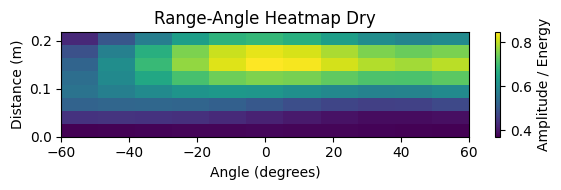

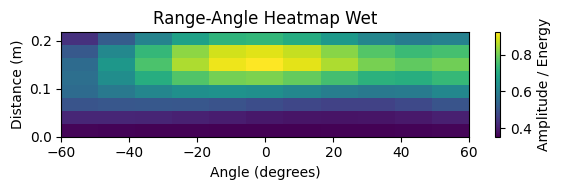

In [39]:
def ra_heatmap(arr, title):
    num_ranges, num_angles = arr.shape
    max_range = range_bin_size * num_ranges  # total range
    angle_bins = np.linspace(-60, 60, num_angles)  # example: ±40° FOV

    # --- Create the heatmap ---
    plt.figure(figsize=(6, 2))
    im = plt.imshow(
        arr,
        aspect='auto',
        origin='lower',
        extent=[angle_bins[0], angle_bins[-1], 0, max_range],
        cmap='viridis'
    )

    plt.colorbar(im, label='Amplitude / Energy')
    plt.xlabel('Angle (degrees)')
    plt.ylabel('Distance (m)')
    plt.title(title)
    plt.tight_layout()
    plt.show()

ra_heatmap(dry_ram_norm_means, "Range-Angle Heatmap Dry")
ra_heatmap(wet_ram_norm_means, "Range-Angle Heatmap Wet")

In [40]:
dry_distance_angle = np.sum(dry_ram_norm_means, axis=0)
wet_distance_angle = np.sum(wet_ram_norm_means, axis=0)

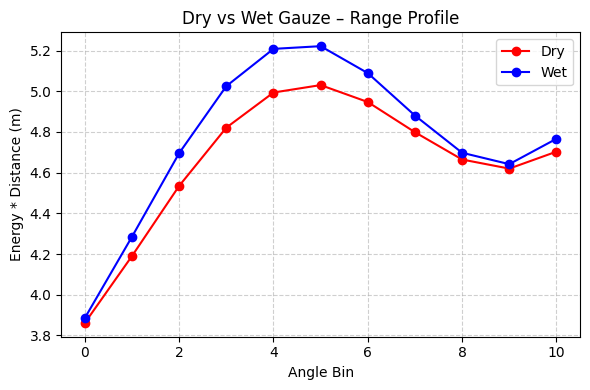

In [41]:
# --- Plot ---
plt.figure(figsize=(6, 4))
plt.plot(dry_distance_angle, 'r-o', label='Dry')
plt.plot(wet_distance_angle, 'b-o', label='Wet')

plt.xlabel('Angle Bin')
plt.ylabel('Energy * Distance (m)')
plt.title('Dry vs Wet Gauze – Range Profile')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()